# Atividade — Meios de Transporte das Mulheres (Brasil, 2022)

**Arquivo utilizado:** `Tabela_13_Meio_de_transporte.xlsx`

A atividade está dividida em duas partes. Na Parte 1 são feitos três *pie charts* para comparar os meios de transporte por cor/raça. Na Parte 2 são usados `melt` e `groupby` para analisar estados e municípios.

> **Observação:** a planilha apresenta **percentuais por cor/raça**, e não números absolutos de mulheres. Por isso, nas perguntas que dizem “em geral”, a análise usa a **média dos percentuais das três categorias de cor/raça disponíveis** (Branca, Preta ou Parda e Indígena).

## Parte 1 — Importação das bibliotecas e leitura do Excel

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

arquivo = 'Tabela_13_Meio_de_transporte.xlsx'
if not os.path.exists(arquivo) and os.path.exists('/mnt/data/Tabela_13_Meio_de_transporte.xlsx'):
    arquivo = '/mnt/data/Tabela_13_Meio_de_transporte.xlsx'

df = pd.read_excel(arquivo, sheet_name='Exemplo gráfico Brasil', skiprows=1)

df.columns = ['Meio de Transporte', 'Branca', 'Preta ou Parda', 'Indígena']

df

,Meio de Transporte,Branca,Preta ou Parda,Indígena
0,A pé,19.4,24.8,37.5
1,Bicicleta,3.2,5.2,5.9
2,Motocicleta ou Mototaxi,9.9,14.2,15.4
3,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2
4,Transporte coletivo,25.2,34.6,22.4
5,Outros,0.5,0.6,3.6


## Parte 1 — Pie charts

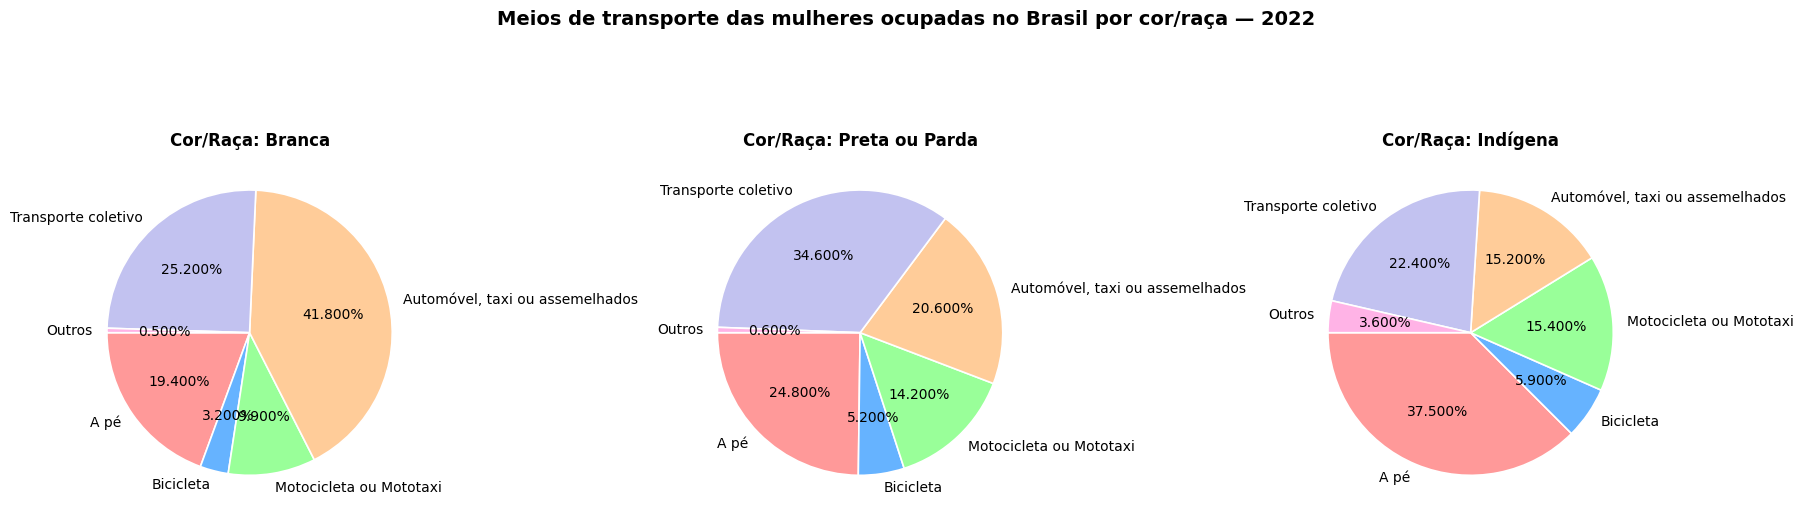

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
grupos = ['Branca', 'Preta ou Parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df[col],
        labels=df['Meio de Transporte'],
        autopct='%1.3f%%',  
        startangle=180,
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Meios de transporte das mulheres ocupadas no Brasil por cor/raça — 2022',
    fontsize=14,
    fontweight='bold',
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('grafico_transporte.png', dpi=300, bbox_inches='tight')
plt.show()

## Análise dos gráficos — Parte 1

A diferença abaixo é calculada em **pontos percentuais (p.p.)**, subtraindo o percentual de um grupo do percentual do outro. Valor negativo significa que o primeiro grupo possui percentual menor naquele meio de transporte.

- **A pé:** Brancas − Pretas/Pardas = **-5,400 p.p.**; Brancas − Indígenas = **-18,100 p.p.**; Pretas/Pardas − Indígenas = **-12,700 p.p.**
- **Bicicleta:** Brancas − Pretas/Pardas = **-2,000 p.p.**; Brancas − Indígenas = **-2,700 p.p.**; Pretas/Pardas − Indígenas = **-0,700 p.p.**
- **Motocicleta ou Mototaxi:** Brancas − Pretas/Pardas = **-4,300 p.p.**; Brancas − Indígenas = **-5,500 p.p.**; Pretas/Pardas − Indígenas = **-1,200 p.p.**
- **Automóvel, taxi ou assemelhados:** Brancas − Pretas/Pardas = **21,200 p.p.**; Brancas − Indígenas = **26,600 p.p.**; Pretas/Pardas − Indígenas = **5,400 p.p.**
- **Transporte coletivo:** Brancas − Pretas/Pardas = **-9,400 p.p.**; Brancas − Indígenas = **2,800 p.p.**; Pretas/Pardas − Indígenas = **12,200 p.p.**
- **Outros:** Brancas − Pretas/Pardas = **-0,100 p.p.**; Brancas − Indígenas = **-3,100 p.p.**; Pretas/Pardas − Indígenas = **-3,000 p.p.**

**Resumo:** o maior contraste aparece no uso de **automóvel**, com 41,8% entre mulheres brancas, 20,6% entre pretas ou pardas e 15,2% entre indígenas. Já no transporte **a pé**, os percentuais são 19,4%, 24,8% e 37,5%, respectivamente. No transporte coletivo, o maior percentual é o de mulheres pretas ou pardas, com 34,6%.

## Parte 2 — Leitura da aba `BR GR UF MU`

In [3]:

raw = pd.read_excel(arquivo, sheet_name='BR GR UF MU', header=None)

estados = [
    'Rondônia', 'Acre', 'Amazonas', 'Roraima', 'Pará', 'Amapá', 'Tocantins',
    'Maranhão', 'Piauí', 'Ceará', 'Rio Grande do Norte', 'Paraíba',
    'Pernambuco', 'Alagoas', 'Sergipe', 'Bahia', 'Minas Gerais',
    'Espírito Santo', 'Rio de Janeiro', 'São Paulo', 'Paraná',
    'Santa Catarina', 'Rio Grande do Sul', 'Mato Grosso do Sul',
    'Mato Grosso', 'Goiás', 'Distrito Federal'
]


df_estados = raw[raw[0].isin(estados)].copy()


print('Quantidade de estados/UFs:', len(df_estados))
display(df_estados[[0]].rename(columns={0: 'Estado'}).reset_index(drop=True))

Quantidade de estados/UFs: 27


,Estado
0,Rondônia
1,Acre
2,Amazonas
3,Roraima
4,Pará
5,Amapá
6,Tocantins
7,Maranhão
8,Piauí
9,Ceará


## Parte 2 — `melt`: transformando os dados para formato longo

In [4]:

dados = df_estados[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]].copy()

dados.columns = [
    'Estado',
    'Branca_A pé', 'Branca_Bicicleta', 'Branca_Motocicleta',
    'Branca_Automóvel', 'Branca_Transporte coletivo', 'Branca_Outros',
    'Preta/Parda_A pé', 'Preta/Parda_Bicicleta', 'Preta/Parda_Motocicleta',
    'Preta/Parda_Automóvel', 'Preta/Parda_Transporte coletivo', 'Preta/Parda_Outros',
    'Indígena_A pé', 'Indígena_Bicicleta', 'Indígena_Motocicleta',
    'Indígena_Automóvel', 'Indígena_Transporte coletivo', 'Indígena_Outros'
]


df_melt = dados.melt(
    id_vars='Estado',
    var_name='Categoria',
    value_name='Percentual'
)
df_melt[['Cor/Raça', 'Meio de Transporte']] = df_melt['Categoria'].str.split('_', n=1, expand=True)

df_melt['Percentual'] = pd.to_numeric(df_melt['Percentual'], errors='coerce')

df_melt.head(10)

,Estado,Categoria,Percentual,Cor/Raça,Meio de Transporte
0,Rondônia,Branca_A pé,11.7,Branca,A pé
1,Acre,Branca_A pé,14.8,Branca,A pé
2,Amazonas,Branca_A pé,13.9,Branca,A pé
3,Roraima,Branca_A pé,11.6,Branca,A pé
4,Pará,Branca_A pé,17.5,Branca,A pé
5,Amapá,Branca_A pé,14.1,Branca,A pé
6,Tocantins,Branca_A pé,15.9,Branca,A pé
7,Maranhão,Branca_A pé,21.0,Branca,A pé
8,Piauí,Branca_A pé,18.2,Branca,A pé
9,Ceará,Branca_A pé,20.5,Branca,A pé


## Pergunta 1 — Qual estado tem mais mulheres, em geral, utilizando o transporte coletivo?

In [5]:

coletivo_estados = (
    df_melt[df_melt['Meio de Transporte'] == 'Transporte coletivo']
    .groupby('Estado', as_index=False)['Percentual']
    .mean()
    .rename(columns={'Percentual': 'Media_Transporte_Coletivo'})
    .sort_values('Media_Transporte_Coletivo', ascending=False)
)

coletivo_estados.head()

,Estado,Media_Transporte_Coletivo
20,Rio de Janeiro,52.233333
6,Distrito Federal,46.000000
25,São Paulo,40.733333
19,Rio Grande do Sul,36.100000
24,Sergipe,33.400000


### Resposta

O estado com maior média dos percentuais de mulheres utilizando **transporte coletivo**, considerando as três categorias de cor/raça, é o **Rio de Janeiro**, com aproximadamente **52,233%**.

> Esse valor é uma média dos percentuais das categorias Branca, Preta ou Parda e Indígena; não representa uma contagem absoluta de mulheres.

## Pergunta 2 — Qual estado tem menos mulheres, em geral, utilizando o transporte coletivo?

In [6]:
coletivo_estados.sort_values('Media_Transporte_Coletivo').head()

,Estado,Media_Transporte_Coletivo
21,Rondônia,4.333333
22,Roraima,8.133333
26,Tocantins,8.600000
0,Acre,9.200000
10,Mato Grosso,9.800000


### Resposta

O estado com menor média dos percentuais de mulheres utilizando **transporte coletivo** é **Rondônia**, com aproximadamente **4,333%**.

## Pergunta 3 — Qual cidade do Brasil tem mais mulheres andando de bicicleta?

In [7]:

df_municipios = raw[
    raw[0].astype(str).str.contains(r'\([A-Z]{2}\)$', regex=True, na=False)
].copy()

for coluna in [2, 8, 14]:
    df_municipios[coluna] = pd.to_numeric(df_municipios[coluna], errors='coerce')

df_municipios['Bicicleta_Media'] = df_municipios[[2, 8, 14]].mean(axis=1)

cidade_bicicleta = (
    df_municipios[['Bicicleta_Media', 0]]
    .sort_values('Bicicleta_Media', ascending=False)
)

cidade_bicicleta.head()

,Bicicleta_Media,0
3918,100.000000,Tuiuti (SP)
190,72.050000,Afuá (PA)
5304,68.900000,Novo Santo Antônio (MT)
2709,67.866667,Lagoa Grande (MG)
5396,64.466667,Britânia (GO)


### Resposta

Considerando a média dos percentuais de bicicleta entre as três categorias de cor/raça, a cidade com maior percentual é **Tuiuti (SP)**, com **100,000%**.

Esse resultado ocorre porque, para a categoria indígena registrada na tabela, o percentual de bicicleta é 100%. Como a planilha trabalha com percentuais por raça e não com números absolutos, esse resultado deve ser interpretado com cuidado.

## Pergunta 4 — Qual cidade do Brasil tem mais mulheres utilizando carro?

In [8]:

for coluna in [4, 10, 16]:
    df_municipios[coluna] = pd.to_numeric(df_municipios[coluna], errors='coerce')


df_municipios['Carro_Media'] = df_municipios[[4, 10, 16]].mean(axis=1)

cidade_carro = (
    df_municipios[['Carro_Media', 0]]
    .sort_values('Carro_Media', ascending=False)
)

cidade_carro.head()

,Carro_Media,0
4388,86.050000,Bom Jesus do Oeste (SC)
4387,74.566667,Bom Jesus (SC)
5107,74.550000,Tupanci do Sul (RS)
3932,71.433333,Valinhos (SP)
3743,71.400000,Piratininga (SP)


### Resposta

Considerando a média dos percentuais de automóvel entre as três categorias de cor/raça, a cidade com maior percentual é **Bom Jesus do Oeste (SC)**, com aproximadamente **86,050%**.

Novamente, trata-se de uma média de percentuais por raça, e não de uma contagem absoluta de mulheres.